# Практика по Линейной регрессии

In [60]:
import numpy as np
import pandas as pd
import seaborn as sns

## Постановка задачи и генерация данных
Задача: Предсказать цену дома, исходя из признаков.
Признаки:
1. Площадь (в кв.м.)
2. Удаленность от центра (км)
3. Возраст здания (лет)

Целевая переменная: Цена дома. $$Стоимость = 2 + 0.1 * Площадь - 0.15 * Удаленность\ от\ центра - 0.05 * Возраст\ здания + Шум$$

In [61]:
'Фиксирую случайность для воспроизведения результатов'
np.random.seed(42)
n_samples = 100

'Генерирую три признака (Features)'
area = np.random.normal(70, 20, n_samples).round(1)      # Площадь (м2)
distance = np.random.uniform(1, 15, n_samples).round(1)  # Удаленность от центра (км)
age = np.random.randint(1, 50, n_samples)                # Возраст здания (лет)

'Формирую значения целевой переменной'
price = (2 + 0.1 * area - 0.15 * distance - 0.05 * age + np.random.normal(0, 0.5, n_samples)).round(2)

'Собираю в DataFrame'
df = pd.DataFrame({
    'Area': area,
    'Distance': distance,
    'Age': age,
    'Price': price
})

df.head()

,Area,Distance,Age,Price
0,79.9,6.8,34,7.07
1,67.2,4.1,21,7.27
2,83.0,2.7,30,9.23
3,100.5,5.7,33,9.18
4,65.3,14.2,28,4.95


In [62]:
'Описательные статистики для всего DataFrame'
df.describe()

,Area,Distance,Age,Price
count,100.000000,100.000000,100.000000,100.000000
mean,67.920000,7.808000,27.550000,6.297900
std,18.167009,4.036767,13.740286,2.110793
min,17.600000,1.100000,1.000000,2.160000
25%,58.000000,4.400000,18.750000,4.905000
50%,67.450000,8.100000,29.000000,6.260000
75%,78.100000,10.725000,39.000000,7.737500
max,107.000000,14.800000,49.000000,11.610000


### Изучаю влияние признаков на целевую переменную

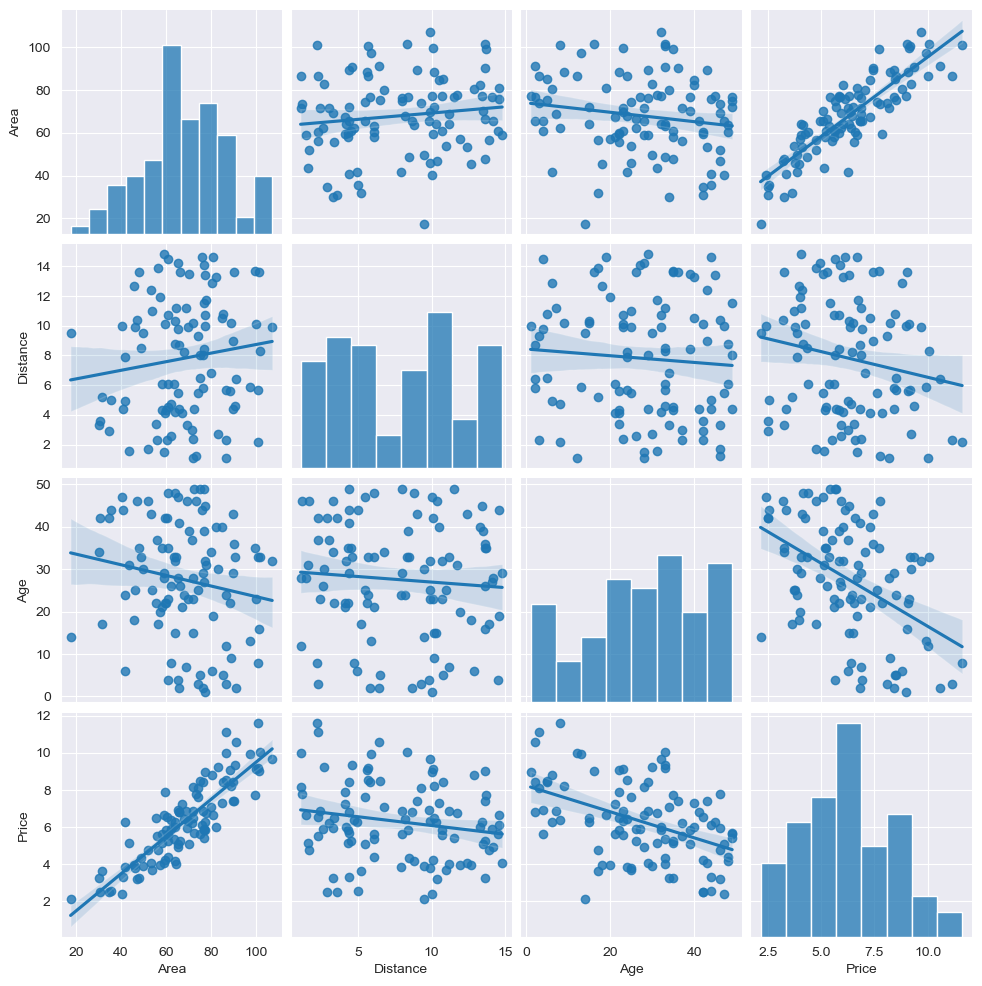

In [63]:
sns.pairplot(data=df, kind='reg');

Можно увидеть Сильную положительную корреляцию между Площадью и Ценой. Этот признак отлично подойдет для аналитической демонстрации простой Линейной регрессии.

## 1. Простая Линейная регрессия (с одним признаком)
Исходя из блока выше, я оставляю только признак Площади дома.

В случае с одним признаком, производная функции стоимости $J(\beta)$ по коэффициентам $\beta$, приравненная к нулю ($\frac{\partial J(\beta)} {\partial \beta}$) приведет нас к готовым формулам для коэффициентов линии регрессии (slope, intercept).

$w$ (slope) - Показывает угол наклона прямой.
$b$ (intercept) - Свободный член или отступ по $OY$
$$\hat{y} = wx + b$$
$$w (slope) = \frac{\sum (x_i - \bar{x}) (y_i - \bar{y})} {\sum (x_i - \bar{x})^2}$$
$$b (intercept) = \bar{y} - w * \bar{x}$$

In [64]:
area_mean = df['Area'].mean()
y_mean = df['Price'].mean()

w = sum([(df['Area'][i] - area_mean) * (df['Price'][i] - y_mean) for i in range(len(df['Area']))]) / sum([(i - area_mean) ** 2 for i in df['Area']])
b = y_mean - w * area_mean

print(f'Результаты для Простой Линейной регрессии:\n'
      f'\tКоэффициент slope (угол наклона) = {w}\n'
      f'\tКоэффициент intercept (отступ по OY) = {b})')

Результаты для Простой Линейной регрессии:
	Коэффициент slope (угол наклона) = 0.10032029155921626
	Коэффициент intercept (отступ по OY) = -0.5158542027019672)


### Пробую предсказать Стоимость дома по Площади = 20

In [65]:
y_simple_predicted = w * 20 + b
print(f'Предсказание Простой Линейной регрессии для Площади = 20: Цена ≈ {round(y_simple_predicted, 3)} млн.руб.')

Предсказание Простой Линейной регрессии для Площади = 20: Цена ≈ 1.491 млн.руб.


## 2. Линейная регрессия с несколькими признаками
Если признаков несколько, то вычисление градиента (частных производных функции стоимости по коэффициентам бета) не приведет к готовым формулам, поэтому тут применяется алгоритм градиентного спуска. Суть в том, что мы считаем градиент (вектор частных производных $\frac{\partial J(\beta)} {\partial \beta}$) и начинаем 'идти' в сторону обратную от градиента (то есть $-\Delta$) до тех пор, пока значение функции стоимости не будет близко к нулю. (К нулю она никогда не придет, иначе это бы значило, что наша прямая идеально проходит через все точки в данных, что в реальном мире - невозможно).


### Разбиение данных на обучающую и тестовую выборку

In [66]:
from sklearn.model_selection import train_test_split

X = df.drop('Price', axis=1) # Матрица всех признаков
y = df['Price'] # Вектор целевой переменной

X_train, X_test, y_train, y_test = train_test_split(X, # Матрица признаков
                                                    y, # Вектор целевой переменной
                                                    test_size=0.2, # 20% от всех данных уйдут в тестовый набор
                                                    random_state=42)

### Стандартизация данных
Привожу все данные в одну размерность, чтобы модель корректно обучилась.

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

### Создание и обучение модели

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

'Обучение модели'
model = LinearRegression()
model.fit(scaled_X_train, y_train)
y_pred = model.predict(scaled_X_test)

'Оценка качества модели'
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Оценка качества модели:\n'
      f'\tСреднеквадратичное отклонение или средняя ошибка = {round(rmse, 3)}\n'
      f'\tR^2 или процентная оценка = {round(r2, 3) * 100}%')


Оценка качества модели:
	Среднеквадратичное отклонение или средняя ошибка = 0.514
	R^2 или процентная оценка = 90.8%


Таким образом, наша модель ошибается на ≈ 0.5 млн.руб., что в целом можно считать приемлемым результатом, так как средняя цена ≈ 6 млн.руб., а значит ошибка относительно среднего ≈ $\frac{0.5} {6} = 0.08$ или 8%

### Предсказание на модели с несколькими признаками

In [69]:
house_features = pd.DataFrame([[20, 5, 30]], columns=['Area', 'Distance', 'Age'])

house_scaled = scaler.transform(house_features)
y_predicted_final = model.predict(house_scaled)

print(f'Предсказания для дома с площадью = 20, Удаленностью от центра = 5 и Возрастом дома = 30: Цена такого дома ≈ = {round(y_predicted_final[0], 3)} млн.руб.')

Предсказания для дома с площадью = 20, Удаленностью от центра = 5 и Возрастом дома = 30: Цена такого дома ≈ = 1.852 млн.руб.
